# **MODELO - TRABAJO FINAL**
**Apellido y Nombres:** Vasquez Caiza Juan Marcelo.

**Carrera:** Ingenieria de Sistemas.

In [2]:
#Librerias basicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Librerias para Pytorch
import torch
import torch.nn as nn
import torch.optim as optim

In [3]:
data = pd.read_csv('dataset.csv', delimiter=',')
print('INFORMACION DE TIPO DE DATOS')
data.info()
print('\nDATOS VACIOS')
print(pd.isnull(data).sum())

INFORMACION DE TIPO DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360000 entries, 0 to 359999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Fecha             360000 non-null  object 
 1   Producto          360000 non-null  object 
 2   Categoría         360000 non-null  object 
 3   Precio            360000 non-null  float64
 4   UnidadesVendidas  360000 non-null  int64  
 5   Descuento         360000 non-null  int64  
 6   Mes               360000 non-null  int64  
 7   Día_Semana        360000 non-null  int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 22.0+ MB

DATOS VACIOS
Fecha               0
Producto            0
Categoría           0
Precio              0
UnidadesVendidas    0
Descuento           0
Mes                 0
Día_Semana          0
dtype: int64


In [4]:
print(data)

             Fecha                   Producto Categoría  Precio  \
0       21/01/2023           Leche Pil UHT 1L   Lácteos    7.25   
1       04/01/2023        Leche Pil Entera 1L   Lácteos    8.58   
2       01/01/2023       Mantequilla Pil 200g  Derivado   12.01   
3       24/01/2023           Leche Pil UHT 1L   Lácteos    7.40   
4       09/01/2023         Leche Pil Light 1L   Lácteos    8.84   
...            ...                        ...       ...     ...   
359995  23/12/2023  Leche Pil Deslactosada 1L   Lácteos    9.24   
359996  09/12/2023    Leche Pil En Polvo 500g   Lácteos   24.07   
359997  05/12/2023        Leche Pil Entera 1L   Lácteos    8.77   
359998  14/12/2023   Yogurt Bebible Pil 200ml  Derivado    4.45   
359999  01/12/2023        Leche Pil Entera 1L   Lácteos    9.06   

        UnidadesVendidas  Descuento  Mes  Día_Semana  
0                    115          0    1           6  
1                    127          5    1           3  
2                     19      

In [5]:
data['Fecha'] = pd.to_datetime(data['Fecha'], dayfirst=True)

data = pd.get_dummies(data, columns=['Producto','Categoría'], drop_first=True)

print(data)

            Fecha  Precio  UnidadesVendidas  Descuento  Mes  Día_Semana  \
0      2023-01-21    7.25               115          0    1           6   
1      2023-01-04    8.58               127          5    1           3   
2      2023-01-01   12.01                19          0    1           7   
3      2023-01-24    7.40               113         20    1           2   
4      2023-01-09    8.84                78          0    1           1   
...           ...     ...               ...        ...  ...         ...   
359995 2023-12-23    9.24                88          0   12           6   
359996 2023-12-09   24.07                25         10   12           6   
359997 2023-12-05    8.77               119          5   12           2   
359998 2023-12-14    4.45                87          0   12           4   
359999 2023-12-01    9.06               110          0   12           5   

        Producto_Crema Pil 200ml  Producto_Leche Condensada Pil 400g  \
0                          

In [6]:
X = data.drop(columns=['Fecha', 'UnidadesVendidas'])
y = data['UnidadesVendidas']

columnas_modelo = X.columns

# **Division de datos**

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Estandarizacion de datos**

In [8]:
from sklearn.preprocessing import StandardScaler

#Estandarizacion de X
scaler_X = StandardScaler()

#ajustar solo en X_train
X_train_scaled = scaler_X.fit_transform(X_train)

#transformar X_test (SIN re-ajustar)
X_test_scaled = scaler_X.transform(X_test)



#Estandarizacion de Y
scaler_y = StandardScaler()

# 1. Ajustar SOLO en y_train. 
# (Necesita .values.reshape(-1, 1) porque es una Serie de Pandas)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))

# 2. Transformar y_test (SIN re-ajustar)
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

In [9]:
X_train_scaled.shape[1]

19

# **Tensores**

In [10]:
torch.cuda.is_available()

True

In [11]:
#Entrenamiento
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).cuda()
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1).cuda()

#Test
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).cuda()
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1).cuda()

# **Modelo MLP**

In [12]:
class MLP(nn.Module):
    #constructor
    def __init__(self, D_in, H1, H2, D_out):

        #llamamos al constructor de la clase madre
        super(MLP, self).__init__()

        #definicion de capas
        self.hidden1 = nn.Linear(D_in, H1)    #capa oculta 1
        self.hidden2 = nn.Linear(H1, H2)      #capa oculta 2
        self.output = nn.Linear(H2, D_out)    #capa de salida
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.output(x)
        return x

Inicializacion del modelo

In [13]:
#iniciamos el modelo
D_in = X_train_scaled.shape[1] 
H1 = 64
H2 = 32
D_out = 1

model = MLP(D_in, H1, H2, D_out)

#codigo para saber si el modelo esta votando los datos en las cantidades correctas
x_prueba = torch.randn(500, D_in)
print(x_prueba)
outputs = model(x_prueba)
outputs.shape

tensor([[-1.6963e+00, -4.5690e-01,  2.8691e-01,  ..., -3.8396e-01,
          9.3393e-01,  2.8179e-02],
        [-1.7555e-01,  1.2899e+00, -3.2302e-01,  ..., -9.7038e-01,
          8.5610e-01,  9.6908e-01],
        [-2.1809e-03,  4.7581e-01,  1.2841e+00,  ...,  1.3289e-04,
          9.8049e-01, -1.3018e+00],
        ...,
        [-5.4104e-01,  7.1981e-01,  1.0311e+00,  ..., -1.7429e+00,
         -2.8491e-01,  4.3980e-01],
        [ 2.0595e-01,  7.3575e-02, -1.5110e+00,  ...,  6.4128e-01,
         -1.6101e+00, -1.5240e+00],
        [-1.5933e+00,  2.1351e-01, -2.1747e-01,  ..., -9.0663e-01,
          2.7347e+00,  8.6836e-01]])


torch.Size([500, 1])

Definir la funcion de **perdida** y el **optimizador**.

In [14]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# **Entrenamiento**

In [15]:
model.to("cuda")
epochs = 10000
log_each = 10
l = []
model.train()

for e in range(1, epochs+1):

    #forward
    y_pred = model(X_train_tensor)

    #loss
    loss = criterion(y_pred, y_train_tensor)
    l.append(loss.item())

    #ponemos a cero los gradientes
    optimizer.zero_grad()

    #backprop calculamos todos los gradientes automaticamente
    loss.backward()

    #update de los pesos
    optimizer.step()

    if not e % log_each:
        print(f"Epoch {e}/{epochs} Loss {np.mean(l):.5f}")

Epoch 10/10000 Loss 0.92182
Epoch 20/10000 Loss 0.82626
Epoch 30/10000 Loss 0.72647
Epoch 40/10000 Loss 0.63519
Epoch 50/10000 Loss 0.55999
Epoch 60/10000 Loss 0.49996
Epoch 70/10000 Loss 0.45323
Epoch 80/10000 Loss 0.41685
Epoch 90/10000 Loss 0.38805
Epoch 100/10000 Loss 0.36475
Epoch 110/10000 Loss 0.34557
Epoch 120/10000 Loss 0.32950
Epoch 130/10000 Loss 0.31582
Epoch 140/10000 Loss 0.30403
Epoch 150/10000 Loss 0.29374
Epoch 160/10000 Loss 0.28468
Epoch 170/10000 Loss 0.27662
Epoch 180/10000 Loss 0.26938
Epoch 190/10000 Loss 0.26284
Epoch 200/10000 Loss 0.25689
Epoch 210/10000 Loss 0.25144
Epoch 220/10000 Loss 0.24643
Epoch 230/10000 Loss 0.24179
Epoch 240/10000 Loss 0.23749
Epoch 250/10000 Loss 0.23347
Epoch 260/10000 Loss 0.22971
Epoch 270/10000 Loss 0.22616
Epoch 280/10000 Loss 0.22281
Epoch 290/10000 Loss 0.21962
Epoch 300/10000 Loss 0.21658
Epoch 310/10000 Loss 0.21366
Epoch 320/10000 Loss 0.21087
Epoch 330/10000 Loss 0.20819
Epoch 340/10000 Loss 0.20562
Epoch 350/10000 Loss 0.

# **Evaluacion**

In [16]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test_tensor) #Predicciones escaladas

In [17]:
# Revertir predicciones
y_pred_reales = scaler_y.inverse_transform(y_pred_scaled.cpu().numpy())

# Revertir valores reales de prueba (para comparar)
y_test_reales = scaler_y.inverse_transform(y_test_scaled) # o puedes usar y_test.values

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test_reales, y_pred_reales))
print(f"El error promedio del modelo es de +/- {rmse:.2f} unidades.")

El error promedio del modelo es de +/- 9.01 unidades.


In [19]:
#MAE
mae = mean_absolute_error(y_test_reales, y_pred_reales)
print(f"Error Absoluto Medio (MAE): {mae:.4f} unidades")

Error Absoluto Medio (MAE): 7.0676 unidades


In [20]:
#R2
r2 = r2_score(y_test_reales, y_pred_reales)
print(f"Coeficiente R-cuadrado (R²): {r2:.4f}")

Coeficiente R-cuadrado (R²): 0.9125


# **Prediccion**

Nuevos Datos: Creamos un diccionario con los datos del dia que queremos predecir.

In [21]:
datos_nuevos = {
    'Precio': 8.50,         # Precio de ese día
    'Descuento': 5,         # Descuento de ese día
    'Mes': 10,              # Mes (ej. Octubre)
    'Día_Semana': 3,        # Día de la semana (ej. Miércoles)
    'Producto': 'Leche Pil Entera 1L', # El producto específico
    'Categoría': 'Lácteos'  # La categoría del producto
}

In [22]:
datos_df = pd.DataFrame([datos_nuevos])
print("1. Datos de entrada (como DataFrame):")
print(datos_df.head())
print("\n")

1. Datos de entrada (como DataFrame):
   Precio  Descuento  Mes  Día_Semana             Producto Categoría
0     8.5          5   10           3  Leche Pil Entera 1L   Lácteos




Aplicamos One-Hot Encoding

In [23]:
# Convertimos el texto ('Producto' y 'Categoría') a 0s y 1s
datos_codificados = pd.get_dummies(datos_df, columns=['Producto', 'Categoría'])

Reindexar Columnas 

In [24]:
datos_procesados = datos_codificados.reindex(columns=columnas_modelo, fill_value=0)
print("2. Datos procesados (One-Hot Encoding y Reindexado):")
print(datos_procesados.head())
print("\n")

2. Datos procesados (One-Hot Encoding y Reindexado):
   Precio  Descuento  Mes  Día_Semana  Producto_Crema Pil 200ml  \
0     8.5          5   10           3                         0   

   Producto_Leche Condensada Pil 400g  Producto_Leche Pil 500ml (mini)  \
0                                   0                                0   

   Producto_Leche Pil Deslactosada 1L  Producto_Leche Pil En Polvo 500g  \
0                                   0                                 0   

   Producto_Leche Pil Entera 1L  Producto_Leche Pil Light 1L  \
0                          True                            0   

   Producto_Leche Pil UHT 1L  Producto_Mantequilla Pil 200g  \
0                          0                              0   

   Producto_Queso Pil Fresco 300g  Producto_Yogurt Bebible Pil 200ml  \
0                               0                                  0   

   Producto_Yogurt Pil Fresa 1L  Producto_Yogurt Pil Natural 1L  \
0                             0             

Estandarizar los datos

In [25]:
datos_scaled = scaler_X.transform(datos_procesados)
print("3. Datos estandarizados (listos para el modelo)")
print(datos_scaled)
print("\n")

3. Datos estandarizados (listos para el modelo)
[[-0.15652037  0.41208846  1.01312678 -0.50317145 -0.16822504 -0.18892276
  -0.30242865 -0.30228502 -0.1468427   2.50161238 -0.35411869 -0.37808445
  -0.20805163 -0.2260927  -0.32896288 -0.25874164 -0.27248867 -0.78557211
   0.8811894 ]]




Predecir con el Modelo MLP

In [26]:
model.eval() # Poner el modelo en modo de evaluación
with torch.no_grad(): # No necesitamos calcular gradientes
    
    # Convertir a tensor y mover a GPU
    tensor_nuevo = torch.tensor(datos_scaled, dtype=torch.float32).cuda()
    
    # Obtener la predicción (aún estará escalada)
    pred_scaled = model(tensor_nuevo)

Interpretar el Resultado

In [27]:
pred_unidades = scaler_y.inverse_transform(pred_scaled.cpu().numpy())

unidades_predichas = pred_unidades[0][0]

print("--- 🚀 PREDICCIÓN FINAL 🚀 ---")
print(f"Para el producto '{datos_nuevos['Producto']}' con precio {datos_nuevos['Precio']}...")
print(f"Se espera vender: {unidades_predichas:.0f} unidades") # .0f para redondear

--- 🚀 PREDICCIÓN FINAL 🚀 ---
Para el producto 'Leche Pil Entera 1L' con precio 8.5...
Se espera vender: 109 unidades


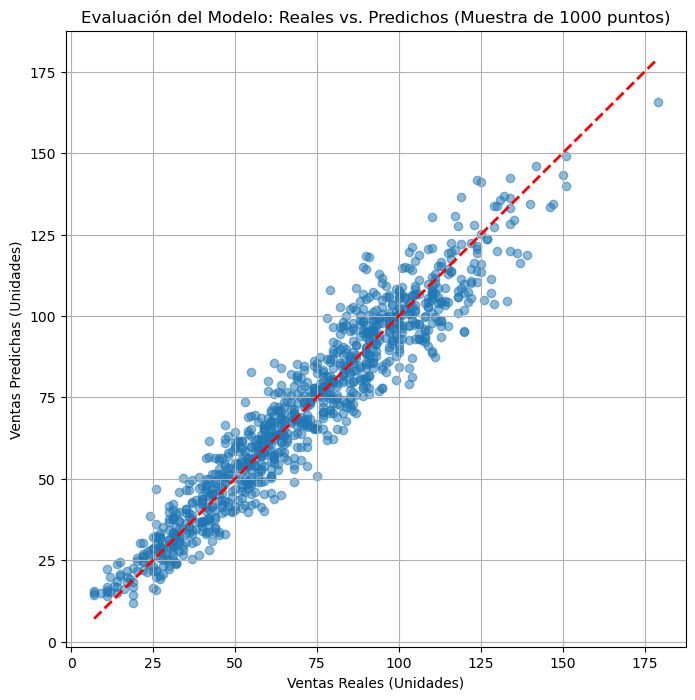

In [28]:
# --- AÑADE ESTA CELDA (ej. Celda 43) ---
# Gráfico de Evaluación (Reales vs. Predichos)

# Aplanamos los arrays para que el gráfico funcione bien
y_test_flat = y_test_reales.flatten()
y_pred_flat = y_pred_reales.flatten()

# Tomamos una muestra aleatoria de 1000 puntos para no saturar el gráfico
indices = np.random.choice(len(y_test_flat), 1000, replace=False)
y_test_sample = y_test_flat[indices]
y_pred_sample = y_pred_flat[indices]


plt.figure(figsize=(8, 8))
plt.scatter(y_test_sample, y_pred_sample, alpha=0.5)
plt.xlabel("Ventas Reales (Unidades)")
plt.ylabel("Ventas Predichas (Unidades)")
plt.title("Evaluación del Modelo: Reales vs. Predichos (Muestra de 1000 puntos)")

# Añadimos una línea roja (y=x). 
# Si el modelo es perfecto, todos los puntos caerían sobre esta línea.
min_val = min(y_test_sample.min(), y_pred_sample.min())
max_val = max(y_test_sample.max(), y_pred_sample.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.grid(True)
plt.show()